# JEM MNIST Pipeline — Run, Analyze, Plot

JEM counterpart of `mnist.ipynb` for `mnist_full_r12 / nat / mlp_h550x480`, plus the matching adversarially-trained (`at`) MLP.

| Figure | What it shows |
|--------|---------------|
| Fig 1 | Sampling: per-class mean sampled digit (from the $\alpha=0.01$ model) |
| Fig 2 | Alpha curve: accuracy / robustness + discriminative/generative loss vs $\alpha$ |
| Fig 3 | Robustness curves: robust acc vs attack $\varepsilon$ — 4 models, plus per-model purification & detection overlays |

The figures, tables, labels and filenames match `mnist.ipynb`. Likelihood-gradient purification keeps the MPS name **Purif. (lk.)**. Locally projected SGLD replaces Gibbs and is reported as **Purif. (samp., $k$)** at the same snapshots $k\in\{1,3,5\}$.

**Prerequisites**: `conda activate bm4tc`, launch Jupyter, run cells top-to-bottom.

**Sections**: §0 run · §0b at · §1 analyze + config · §2–4 figures · §5 tables · §6 detection.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /Users/jose/VSCodeProjects/bm4tc


In [2]:
import matplotlib

USE_LATEX = True
if USE_LATEX:
    matplotlib.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "text.latex.preamble": r"\usepackage{mathptmx}",
    })
else:
    matplotlib.rcParams.update({"text.usetex": False})

PCT = r"\%" if USE_LATEX else "%"

---
## §0  Run the nat alpha experiments

The same three-stage pipeline as MPS: discriminative HPO ($\alpha=0$) → warm-started generative HPO ladder → seed sweeps. JEM automatically writes each completed HPO's best parameters into the matching seed-sweep YAML.

In [3]:
A0_MODEL = "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt"
ALPHA_RUNS = [("a001", 0.01), ("a01", 0.1), ("a02", 0.2), ("a05", 0.5), ("a1", 1.0)]

print("# Stage 1 - discriminative HPO and seed sweep:")
print("python -m baselines.jem.train --multirun +experiment=hpo/a0 device=cuda:0")
print("python -m baselines.jem.train --multirun +experiment=seed_sweep/a0 device=cuda:0")

print("\n# Stage 2 - warm-started JEM HPO ladder:")
for name, alpha in ALPHA_RUNS:
    print("python -m baselines.jem.train --multirun +experiment=hpo/pretrained "
          f"run_name=pretrained_{name} trainer.alpha={alpha} model_path={A0_MODEL} device=cuda:0")

print("\n# Stage 3 - seed sweeps (the HPO callback has filled their YAMLs):")
for name, _ in ALPHA_RUNS:
    print("python -m baselines.jem.train --multirun "
          f"+experiment=seed_sweep/{name} model_path={A0_MODEL} device=cuda:0")

# Stage 1 - discriminative HPO and seed sweep:
python -m baselines.jem.train --multirun +experiment=hpo/a0 device=cuda:0
python -m baselines.jem.train --multirun +experiment=seed_sweep/a0 device=cuda:0

# Stage 2 - warm-started JEM HPO ladder:
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name=pretrained_a001 trainer.alpha=0.01 model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name=pretrained_a01 trainer.alpha=0.1 model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name=pretrained_a02 trainer.alpha=0.2 model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0
python -m baselines.jem.train --multirun +experiment=hpo/pretrained run_name

---
## §0b  Run the adversarially-trained (`at`) model

As in MPS, the `at` model warm-starts from the selected $\alpha=0$ checkpoint and is trained after `seed_sweep/a0`.

In [4]:
print("# Step 1 - AT HPO (automatically updates seed_sweep/at.yaml):")
print(f"python -m baselines.jem.train --multirun +experiment=hpo/at model_path={A0_MODEL} device=cuda:0")
print("\n# Step 2 - AT seed sweep (5 seeds):")
print(f"python -m baselines.jem.train --multirun +experiment=seed_sweep/at model_path={A0_MODEL} device=cuda:0")

# Step 1 - AT HPO (automatically updates seed_sweep/at.yaml):
python -m baselines.jem.train --multirun +experiment=hpo/at model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0

# Step 2 - AT seed sweep (5 seeds):
python -m baselines.jem.train --multirun +experiment=seed_sweep/at model_path=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/2/models/model.pt device=cuda:0


---
## §1  Analyze + configure output dirs

`baselines.jem.sweep` turns each multirun directory into the same `evaluation_data.csv`-style result used by the MPS notebook. The compact summary reports **Purif. (lk.)** and locally projected SGLD as **Purif. (samp., $k$)** for $k=1,3,5$. Each SGLD sweep uses 20 transitions locally constrained by $\delta=0.2$; the next sweep is recentered on the previous output. `step_size=0.01` and `noise_std=0.005` are fixed across models.

In [5]:
from src.utils.paths import data_root

SWEEP_DIRS = {
    "seed_sweep_a0":   "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607",
    "seed_sweep_a001": "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607",
    "seed_sweep_a01":  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607",
    "seed_sweep_a02":  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607",
    "seed_sweep_a05":  "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a05_2607",
    "seed_sweep_a1":   "outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a1_2607",
    "at_seed_sweep":   "outputs/baselines/jem/mnist_full_r12/at/mlp_h550x480/seed_sweep/at_2707",
}
ALPHA_OF = {
    "seed_sweep_a0": 0.0, "seed_sweep_a001": 0.01, "seed_sweep_a01": 0.1,
    "seed_sweep_a02": 0.2, "seed_sweep_a05": 0.5, "seed_sweep_a1": 1.0,
}
PURIFY_RADIUS = 0.2
SAMPLE_PURIFY_DELTA = 0.2
SAMPLE_STEPS_PER_SWEEP = 20
SAMPLE_STEP_SIZE = 0.01
SAMPLE_NOISE_STD = 0.005
ALPHA_SAMPLE_K = 1
DEFENSE_SAMPLE_K = 5

print("# Analysis commands (run from project root):")
for sweep_dir in SWEEP_DIRS.values():
    print(
        f"python -m baselines.jem.sweep {sweep_dir} --device cuda:0 "
        f"--sampling-radius {SAMPLE_PURIFY_DELTA} --sampling-sweeps 1 3 5 "
        f"--sampling-steps-per-sweep {SAMPLE_STEPS_PER_SWEEP} "
        f"--sampling-step-size {SAMPLE_STEP_SIZE} "
        f"--sampling-noise-std {SAMPLE_NOISE_STD}"
    )

# Analysis commands (run from project root):
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 5 --sampling-steps-per-sweep 20 --sampling-step-size 0.01 --sampling-noise-std 0.005
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 5 --sampling-steps-per-sweep 20 --sampling-step-size 0.01 --sampling-noise-std 0.005
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 5 --sampling-steps-per-sweep 20 --sampling-step-size 0.01 --sampling-noise-std 0.005
python -m baselines.jem.sweep outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607 --device cuda:0 --sampling-radius 0.2 --sampling-sweeps 1 3 5 --sampling-steps-per-sweep 20 --sampling-s

In [6]:
import pandas as pd

ANALYSIS_CSV = {
    key: data_root() / "analysis/outputs" / Path(path).relative_to("outputs") / "evaluation_data.csv"
    for key, path in SWEEP_DIRS.items()
}
required_sampling = {f"sgld_purify_acc/0.1/{k}" for k in (1, 3, 5)}
for key, path in ANALYSIS_CSV.items():
    if not path.exists():
        status = "MISSING"
    else:
        columns = set(pd.read_csv(path, nrows=0).columns)
        status = "OK" if required_sampling <= columns else "STALE: rerun analysis"
    print(key, path, status)

seed_sweep_a0 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/evaluation_data.csv OK
seed_sweep_a001 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607/evaluation_data.csv OK
seed_sweep_a01 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607/evaluation_data.csv OK
seed_sweep_a02 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a02_2607/evaluation_data.csv OK
seed_sweep_a05 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a05_2607/evaluation_data.csv OK
seed_sweep_a1 /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a1_2607/evaluation_data.csv OK
at_seed_sweep /Users/jose/VSCodeProjects/bm4tc/analysis/outputs/baselines/jem/

---
## §1b  Purification radius — compare & fix

The same likelihood-purification radius comparison as MPS, using `uq_purify_acc/{eps}/{r}`. Choose a radius and set `PURIFY_RADIUS` above. Output: `figures/jem_mnist/purify_radius/purify_acc_vs_radius.png`.

In [7]:
from baselines.jem.plots import plot_purification_radii

RADIUS_MODELS = {
    r"$\alpha{=}0$": ANALYSIS_CSV["seed_sweep_a0"],
    r"$\alpha{=}0.01$": ANALYSIS_CSV["seed_sweep_a001"],
    "AT": ANALYSIS_CSV["at_seed_sweep"],
}
plot_purification_radii(
    RADIUS_MODELS,
    PROJECT_ROOT / "figures/jem_mnist/purify_radius/purify_acc_vs_radius.png",
)

PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/purify_radius/purify_acc_vs_radius.png')

---
## §2  Figure 1 — Sampling (the $\alpha=0.01$ model)

Per-class **mean** sampled digit in the same 2×5 grid as MPS. JEM uses long class-conditional SGLD chains. Output: `figures/jem_mnist/sampling/mnist_samples.png`.

Best alpha=0.01 run: /Users/jose/VSCodeProjects/bm4tc/outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607/1 (acc=0.9801, device=cpu)


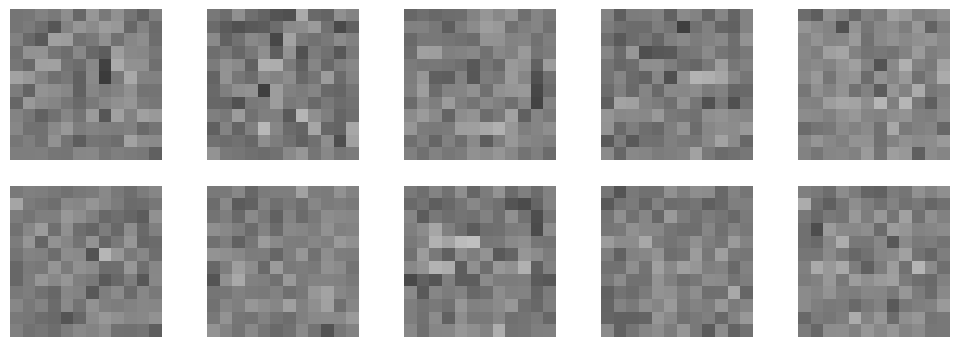

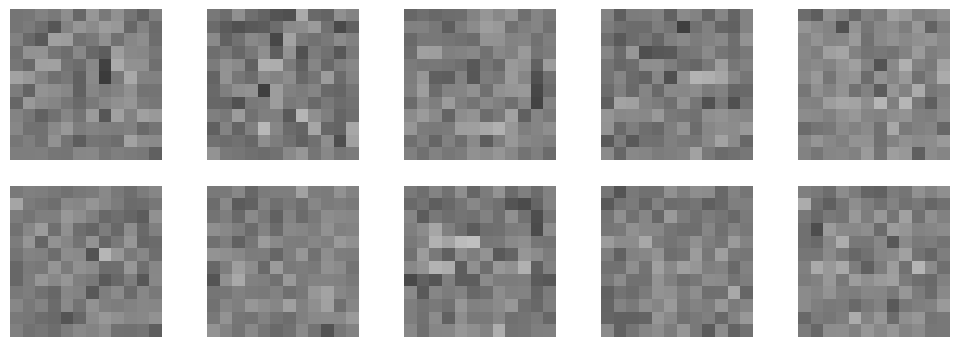

In [8]:
import pandas as pd
import torch
from baselines.jem.generate import sample_and_plot

SAMPLE_KEY = "seed_sweep_a001"
N_PER_CLASS = 64
SAMPLE_STEPS = 1000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sample_df = pd.read_csv(ANALYSIS_CSV[SAMPLE_KEY])
best = sample_df.loc[sample_df["acc"].idxmax()]
run_dir = Path(best["run_path"])
print(f"Best alpha=0.01 run: {run_dir} (acc={best['acc']:.4f}, device={DEVICE})")

save_dir = PROJECT_ROOT / "figures/jem_mnist/sampling"
fig = sample_and_plot(
    run_dir, n_per_class=N_PER_CLASS, steps=SAMPLE_STEPS,
    save_dir=save_dir, device=DEVICE,
)
fig.suptitle("")
for ax in fig.axes:
    ax.set_title("")
fig.savefig(save_dir / "mnist_samples.png", dpi=150, bbox_inches="tight")
fig

---
## §3  Figure 2 — Alpha curve (two figures)

The same six alpha sweeps and filenames as MPS:

- `alpha_curve_accuracy.png`: Clean, Rob., Purif. (lk.) and Purif. (samp., $k=1$) accuracy.
- `alpha_curve_nll.png`: discriminative loss and the JEM generative CD surrogate.

In [9]:
from baselines.jem.plots import plot_alpha_curves

NAT_KEYS = ["seed_sweep_a0", "seed_sweep_a001", "seed_sweep_a01",
            "seed_sweep_a02", "seed_sweep_a05", "seed_sweep_a1"]
alpha_csv = {ALPHA_OF[key]: ANALYSIS_CSV[key] for key in NAT_KEYS}
plot_alpha_curves(
    alpha_csv,
    PROJECT_ROOT / "figures/jem_mnist/alpha",
    epsilon=0.3,
    radius=PURIFY_RADIUS,
    sampling_sweep=ALPHA_SAMPLE_K,
)

(PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/alpha/alpha_curve_accuracy.png'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/alpha/alpha_curve_nll.png'))

---
## §4  Figure 3 — Defense comparison (model × defense, per attack strength)

The MPS bar groups and names are preserved: **Clean**, **Rob.**, **Purif. (lk.)** and **Accept ($q=10\%$)**. Locally projected SGLD replaces Gibbs and is shown as **Purif. (samp., $k=5$)**. Outputs: `defense_comparison_eps{0.1,0.2,0.3}.png`.

In [10]:
from baselines.jem.plots import plot_defense_comparison

MODELS = {
    r"$\alpha{=}0$": ANALYSIS_CSV["seed_sweep_a0"],
    r"$\alpha{=}0.01$": ANALYSIS_CSV["seed_sweep_a001"],
    r"$\alpha{=}0.5$": ANALYSIS_CSV["seed_sweep_a05"],
    "AT": ANALYSIS_CSV["at_seed_sweep"],
}
plot_defense_comparison(
    MODELS,
    PROJECT_ROOT / "figures/jem_mnist/robustness",
    radius=PURIFY_RADIUS,
    sampling_sweep=DEFENSE_SAMPLE_K,
    percentile=10,
)

[PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/robustness/defense_comparison_eps0.1.png'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/robustness/defense_comparison_eps0.2.png'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/robustness/defense_comparison_eps0.3.png')]

---
## §5  Tables (LaTeX + plain text)

The same `detection.tex/.txt`, `joint_vs_normal_eps{eps}.tex` and `joint_vs_normal.txt` outputs as MPS, under `figures/jem_mnist/tables/`.

In [11]:
from baselines.jem.tables import write_mnist_tables

TABLE_MODELS = {
    "seed_sweep_a0": (r"$\alpha{=}0$", ANALYSIS_CSV["seed_sweep_a0"]),
    "seed_sweep_a001": (r"$\alpha{=}0.01$", ANALYSIS_CSV["seed_sweep_a001"]),
    "seed_sweep_a05": (r"$\alpha{=}0.5$", ANALYSIS_CSV["seed_sweep_a05"]),
    "at_seed_sweep": ("AT", ANALYSIS_CSV["at_seed_sweep"]),
}
write_mnist_tables(
    TABLE_MODELS,
    PROJECT_ROOT / "figures/jem_mnist/tables",
    radius=PURIFY_RADIUS,
    sampling_sweep=DEFENSE_SAMPLE_K,
    percentile=10,
)

[PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/detection.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/detection.txt'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal_eps0.1.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal_eps0.2.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal_eps0.3.tex'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/tables/joint_vs_normal.txt')]

---
## §6  Figure 4 — OOD-detection effectiveness vs threshold

The same likelihood-detector curves as MPS: accepted accuracy and adversarial detection rate versus clean rejection percentile. No external dataset is used. Outputs: `accept_acc_vs_threshold_{key}.png`.

In [12]:
from baselines.jem.plots import plot_detection_thresholds

DET_SWEEPS = {
    "seed_sweep_a0": (r"$\alpha{=}0$", ANALYSIS_CSV["seed_sweep_a0"]),
    "seed_sweep_a001": (r"$\alpha{=}0.01$", ANALYSIS_CSV["seed_sweep_a001"]),
    "at_seed_sweep": ("AT", ANALYSIS_CSV["at_seed_sweep"]),
}
plot_detection_thresholds(
    DET_SWEEPS,
    PROJECT_ROOT / "figures/jem_mnist/detection",
    percentiles=(1, 5, 10, 20),
)

[PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/detection/accept_acc_vs_threshold_seed_sweep_a0.png'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/detection/accept_acc_vs_threshold_seed_sweep_a001.png'),
 PosixPath('/Users/jose/VSCodeProjects/bm4tc/figures/jem_mnist/detection/accept_acc_vs_threshold_at_seed_sweep.png')]